# Background ROI Playground

Use this notebook to explore background modeling in a chosen ROI.


## Notes

- ROI format is `(y0, y1, x0, x1)` (Python slicing: y1/x1 are exclusive).
- The widgets below update a red rectangle over the image and store the ROI in `roi_state["roi"]`.


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display
from astropy.io import fits
from importlib import reload

import sys
sys.path.append("..")

path = "../test-data/of9b05010_flt.fits"
# For HST FLT files, science data is typically in extension 1 (SCI)
# and DQ in extension 3.
data = fits.getdata(path, ext=1)
dq = fits.getdata(path, ext=3)


In [3]:
# Provide your own 2D image data here (e.g., from a FITS file).
# If `data` is not defined yet, build a simple synthetic example.
try:
    data
except NameError:
    ny, nx = 200, 300
    yy, xx = np.indices((ny, nx))
    data = (
        10
        + 0.01 * xx
        + 0.02 * yy
        + 0.0001 * xx * yy
        + np.random.normal(0.0, 0.2, size=(ny, nx))
    )

data = np.asarray(data, dtype=float)


In [ ]:
# def _show_roi(img, x_range, y_range, vmin=None, vmax=None):
#     fig, ax = plt.subplots(figsize=(6, 4))
#     ax.imshow(img, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
#     x0, x1 = x_range
#     y0, y1 = y_range
#     rect = Rectangle(
#         (x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", lw=2
#     )
#     ax.add_patch(rect)
#     ax.set_title(f"ROI: y[{y0}:{y1}], x[{x0}:{x1}]")
#     plt.show()


# def make_roi_widgets(img):
#     ny, nx = img.shape
#     x_slider = widgets.IntRangeSlider(
#         value=[0, max(1, nx // 3)],
#         min=0,
#         max=nx - 1,
#         step=1,
#         description="x",
#         continuous_update=False,
#     )
#     y_slider = widgets.IntRangeSlider(
#         value=[0, max(1, ny // 3)],
#         min=0,
#         max=ny - 1,
#         step=1,
#         description="y",
#         continuous_update=False,
#     )
#     vmin = widgets.FloatText(value=float(np.nanpercentile(img, 5)), description="vmin")
#     vmax = widgets.FloatText(value=float(np.nanpercentile(img, 95)), description="vmax")
#     return x_slider, y_slider, vmin, vmax


# roi_state = {"roi": None}

# x_slider, y_slider, vmin_box, vmax_box = make_roi_widgets(np.cbrt(data))


# def _update_roi(x, y, vmin, vmax):
#     roi_state["roi"] = (y[0], y[1], x[0], x[1])
#     _show_roi(data, x, y, vmin=vmin, vmax=vmax)


# out = widgets.interactive_output(
#     _update_roi,
#     {"x": x_slider, "y": y_slider, "vmin": vmin_box, "vmax": vmax_box},
# )

# display(
#     widgets.VBox([x_slider, y_slider, widgets.HBox([vmin_box, vmax_box])]), out
# )


Output()

In [ ]:
# # The current ROI selection (y0, y1, x0, x1):
# roi = roi_state["roi"]
# roi


(251, 553, 483, 760)

In [35]:
# fix ROI for future use
roi = (251, 553, 483, 760) 

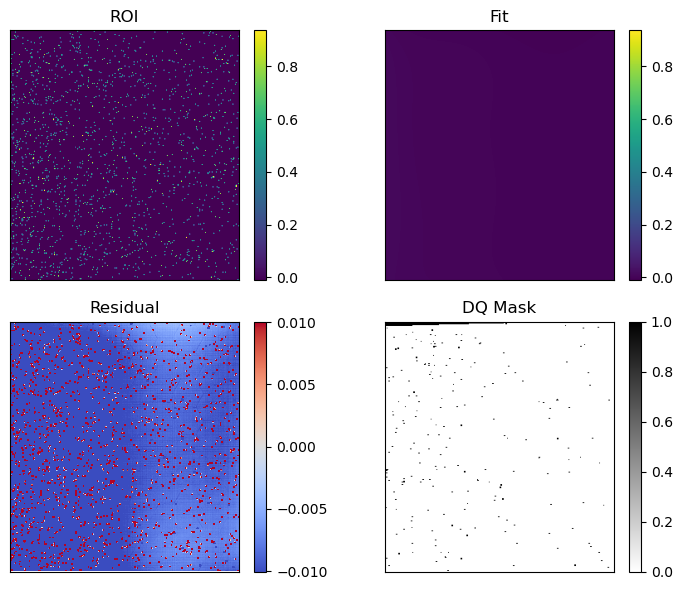

<module 'utilities' from '/Users/parke/Repos/airglow/notebooks/../utilities.py'>

In [42]:
import models as models

# Fit polynomial surface on current ROI and plot data, fit, residual, mask

y0, y1, x0, x1 = roi
roi_data = data[y0:y1, x0:x1]
roi_dq = dq[y0:y1, x0:x1]

flags = [1, 2, 4, 16, 32, 256, 512, 8192]
dq_mask = 0
for flag in flags:
    dq_mask |= flag
bad = (roi_dq & dq_mask) != 0

# Poisson-like weights to de-weight bright pixels
# Use w = 1 / sqrt(max(data, 0) + 1) within the ROI
weights = np.zeros_like(data, dtype=float)
roi_weights = 1.0 / np.sqrt(np.clip(roi_data, 0.0, None) + 1.0)
weights[y0:y1, x0:x1] = roi_weights

fit_result = models.fit_poly_surface_2d(
    data, (y0, y1, x0, x1), order=5, mask=bad, weights=weights
)
fit = fit_result["model"]
resid = roi_data - fit

vmin = np.nanpercentile(roi_data, 5)
vmax = np.nanpercentile(roi_data, 98)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()
im0 = axes[0].imshow(roi_data, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("ROI")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(fit, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Fit")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

resid_limit = np.nanpercentile(np.abs(resid), 50)
im2 = axes[2].imshow(resid, origin="lower", cmap="coolwarm", vmin=-resid_limit, vmax=resid_limit)
axes[2].set_title("Residual")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(bad, origin="lower", cmap="gray_r")
axes[3].set_title("DQ Mask")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
reload(models)


In [38]:
# Check whether residuals average to ~0 over large areas
# Define block size (pixels) and minimum number of positive-count pixels per block
block_size = (50, 50)
min_positive = 10

h, w = resid.shape
by, bx = block_size
trim_h = (h // by) * by
trim_w = (w // bx) * bx

def get_block_stats(matrix, mask_blocks=None, desc="Array"):
    # matrix: trimmed 2D data to analyze
    blocks = matrix[:trim_h, :trim_w].reshape(trim_h // by, by, trim_w // bx, bx)
    if mask_blocks is not None:
        block_means = np.nanmean(blocks, axis=(1, 3))
        valid = mask_blocks
    else:
        block_means = np.nanmean(blocks, axis=(1, 3))
        valid = np.full(block_means.shape, True, dtype=bool)
    stats = {}
    stats["mean"] = np.nanmean(block_means[valid])
    stats["median"] = np.nanmedian(block_means[valid])
    stats["block_means"] = block_means
    stats["valid_mask"] = valid
    stats["description"] = desc
    return stats

resid_trim = resid[:trim_h, :trim_w]
roi_trim = roi_data[:trim_h, :trim_w]
fit_trim = fit[:trim_h, :trim_w]

roi_blocks = roi_trim.reshape(trim_h // by, by, trim_w // bx, bx)
pos_counts = np.sum(roi_blocks > 0, axis=(1, 3))
valid_blocks = pos_counts >= min_positive

print(f"Block size: {block_size}, min positive per block: {min_positive}")
print(f"Blocks with enough positive pixels: {np.sum(valid_blocks)} / {valid_blocks.size}")

roi_stats = get_block_stats(roi_trim, mask_blocks=valid_blocks, desc="ROI")
fit_stats = get_block_stats(fit_trim, mask_blocks=valid_blocks, desc="Model")
resid_stats = get_block_stats(resid_trim, mask_blocks=valid_blocks, desc="Residuals")

if np.any(valid_blocks):
    for stats in [roi_stats, fit_stats, resid_stats]:
        print(f"{stats['description']}:")
        print(f"  Mean of block means (valid blocks): {stats['mean']:.6g}")
        print(f"  Median of block means (valid blocks): {stats['median']:.6g}")
else:
    print("No blocks met the minimum positive-pixel threshold.")


Block size: (50, 50), min positive per block: 10
Blocks with enough positive pixels: 30 / 30
ROI:
  Mean of block means (valid blocks): 0.0102049
  Median of block means (valid blocks): 0.00839225
Model:
  Mean of block means (valid blocks): 0.000824853
  Median of block means (valid blocks): -0.00027752
Residuals:
  Mean of block means (valid blocks): 0.00938005
  Median of block means (valid blocks): 0.00895679


In [18]:
np.median(resid)

-0.018700678794464402

In [ ]:
import models
reload(models)

# RBF fit sandbox (adjust parameters below)
rbf_function = "thin_plate"  # e.g., "thin_plate", "multiquadric", "linear", "inverse", "gaussian"
rbf_smooth = 10.0
rbf_epsilon = None  # try a float if using multiquadric or gaussian

rbf_result = models.fit_rbf_surface_2d(
    data,
    (y0, y1, x0, x1),
    mask=bad,
    function=rbf_function,
    smooth=rbf_smooth,
    epsilon=rbf_epsilon,
    subsample=(20, 20),
)
rbf_fit = rbf_result["model"]
rbf_resid = roi_data - rbf_fit

vmin = np.nanpercentile(roi_data, 5)
vmax = np.nanpercentile(roi_data, 98)
resid_limit = np.nanpercentile(np.abs(rbf_resid), 50)

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
axes[0].imshow(roi_data, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("ROI")
axes[1].imshow(rbf_fit, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("RBF Fit")
axes[2].imshow(rbf_resid, origin="lower", cmap="coolwarm", vmin=-resid_limit, vmax=resid_limit)
axes[2].set_title("RBF Residual")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
